### Step0: 環境初始化與基礎設定 (全新 Colab 必備)

此步驟將完成全新環境的基礎建置：
1. **掛載 Google Drive**：以讀取您存在硬碟中的空間圖資 (村里界 Shapefile)。
2. **安裝核心套件**：安裝空間內插專用的 `pykrige`。
3. **中文字型設定**：下載並設定 Noto Sans TC，確保後續 Matplotlib 畫圖時中文不會變成「豆腐塊 (方框)」。

In [ ]:
# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. 安裝必要的空間套件
!pip install pykrige -q

# 3. 載入套件與設定中文字型
import os
import requests
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from shapely.geometry import Point
from pykrige.ok import OrdinaryKriging
from google.colab import userdata

warnings.filterwarnings("ignore")

print("⚙️ 正在設定中文字型...")
font_path = '/tmp/NotoSansTC.otf'
if not os.path.exists(font_path):
    !wget -q -O {font_path} https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 環境初始化與字型設定完成！")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.4 MB/s eta 0:00:00
⚙️ 正在設定中文字型...
✅ 環境初始化與字型設定完成！


### Step1: 載入村里邊界與設定分析範圍

在新環境中，我們必須重新載入基礎地圖資料，並定義我們這次分析的「目標區域 (大安區)」。
1. **讀取全台村里界 SHP**。
2. **文字清理**：統一「臺」與「台」的寫法，避免篩選失敗。

In [ ]:
print("🗺️ 正在建立六大行政區邊界過濾器 (大同、萬華、中山、中正、大安、松山)...")

# 1. 讀取全台村里界 SHP (請確保路徑正確)
shp_path = "/content/drive/MyDrive/GIS_data/全台村里界shp/VILLAGE_NLSC_121_1150306.shp"
gdf_villages = gpd.read_file(shp_path)

# 2. 清理文字不一致問題
gdf_villages['COUNTYNAME'] = gdf_villages['COUNTYNAME'].str.replace('台北市', '臺北市')
gdf_villages['TOWNNAME'] = gdf_villages['TOWNNAME'].str.replace('台', '臺')

# 3. 設定目標六大行政區
target_districts = ['大同區', '萬華區', '中山區', '中正區', '大安區', '松山區']

# 4. 進行過濾
gdf_target = gdf_villages[(gdf_villages['COUNTYNAME'] == '臺北市') &
                          (gdf_villages['TOWNNAME'].isin(target_districts))].copy()

# 5. 座標轉換與邊界生成
gdf_villages_twd97 = gdf_target.to_crs(epsg=3826).copy()
boundary_poly_twd97 = gdf_villages_twd97.dissolve().geometry.iloc[0]
boundary_poly_wgs84 = gdf_target.to_crs(epsg=4326).dissolve().geometry.iloc[0]

print(f"✅ 邊界更新完成！這六個行政區共包含 {len(gdf_target)} 個村里。")

🗺️ 正在建立六大行政區邊界過濾器 (大同、萬華、中山、中正、大安、松山)...
✅ 邊界更新完成！這六個行政區共包含 220 個村里。


### Step2-1: 介接中央氣象署 (CWA) 即時觀測資料

從 Colab Secrets 讀取 API 金鑰，並向氣象署發送請求。為了讓 Kriging 內插的邊緣精確，我們會把大安區邊界往外擴張 20 公里，把周圍的測站（如信義區、中正區，甚至新北市的測站）一起抓進來當作運算參考點。

In [ ]:
print("📡 正在向中央氣象署擷取最新即時觀測資料...")

try:
    CWA_API_KEY = userdata.get('CWA_API_KEY')
except Exception as e:
    print("❌ 無法讀取金鑰！請點擊 Colab 左側的 🔑 (Secrets) 圖示，新增一筆名為 'CWA_API_KEY' 的金鑰。")
    raise e

url = f"https://opendata.cwa.gov.tw/api/v1/rest/datastore/O-A0003-001?Authorization={CWA_API_KEY}&format=JSON"

response = requests.get(url)
if response.status_code == 200:
    data = response.json()
    stations = data['records']['Station']

    station_list = []
    for st in stations:
        try:
            name = st['StationName']
            lat = float(st['GeoInfo']['Coordinates'][1]['StationLatitude'])
            lon = float(st['GeoInfo']['Coordinates'][1]['StationLongitude'])
            temp = float(st['WeatherElement']['AirTemperature'])

            # 過濾掉無效溫度 (故障時常為 -99)
            if temp > -50:
                station_list.append({'StationName': name, 'Lon': lon, 'Lat': lat, 'Temperature': temp})
        except (KeyError, ValueError, TypeError):
            continue

    df_stations = pd.DataFrame(station_list)
    gdf_stations = gpd.GeoDataFrame(
        df_stations, geometry=gpd.points_from_xy(df_stations.Lon, df_stations.Lat), crs="EPSG:4326"
    ).to_crs(epsg=3826)

    print(f"✅ 成功抓取全台 {len(gdf_stations)} 個有效測站。")

    # 建立目標區外推 20km 的緩衝區，篩選出「大臺北周邊」測站供內插使用
    buffer_zone = boundary_poly_twd97.buffer(20000)
    gdf_stations_local = gdf_stations[gdf_stations.intersects(buffer_zone)].copy()
    print(f"📍 篩選出五區周邊共 {len(gdf_stations_local)} 個測站。")
else:
    print(f"❌ API 請求失敗，狀態碼：{response.status_code}")

📡 正在向中央氣象署擷取最新即時觀測資料...
✅ 成功抓取全台 349 個有效測站。
📍 篩選出五區周邊共 35 個測站。


### Step2-2: 介接環境部 (MOENV) 即時空氣品質指標 (AQI)

本步驟將從 Colab Secrets 讀取環境部 API 金鑰 (`MOENV_API_KEY`)，並呼叫環境部資料開放平台的 AQI 測站即時資料端點 (`aqx_p_432`)。
1. **發送請求**：擷取全台灣所有空品測站的即時 AQI 數值。
2. **資料解析與清洗**：過濾掉維護中或無效數值 (空值或非數字) 的測站。
3. **空間過濾**：同樣利用大安區外推 20 公里的緩衝區，篩選出大臺北周邊的 AQI 測站，供後續 Kriging 內插使用。

In [ ]:
import requests
import pandas as pd
import geopandas as gpd
from google.colab import userdata

print("📡 正在向環境部擷取最新即時空品 (AQI) 資料...")

# 1. 讀取環境部 API 金鑰
try:
    MOENV_API_KEY = userdata.get('MOENV_API_KEY')
except Exception as e:
    print("❌ 無法讀取金鑰！請確認 Colab 左側的 🔑 (Secrets) 中已設定 'MOENV_API_KEY'。")
    raise e

# 2. 環境部 AQI 開放資料 API 端點
moenv_url = f"https://data.moenv.gov.tw/api/v2/aqx_p_432?api_key={MOENV_API_KEY}&limit=1000&sort=ImportDate desc&format=JSON"

response = requests.get(moenv_url)

if response.status_code == 200:
    data = response.json()

    # ★ 治本修正：動態判斷 API 回傳的 JSON 結構是字典還是列表
    if isinstance(data, dict):
        aqi_records = data.get('records', [])
    elif isinstance(data, list):
        aqi_records = data
    else:
        aqi_records = []
        print("⚠️ 警告：無法解析的資料格式。")

    station_list = []
    for st in aqi_records:
        try:
            name = st.get('sitename')
            lon = float(st.get('longitude'))
            lat = float(st.get('latitude'))
            aqi_str = st.get('aqi')

            # 過濾掉儀器維護中、或是沒有 AQI 數值的空站
            if aqi_str and aqi_str.isdigit():
                aqi = float(aqi_str)
                station_list.append({'StationName': name, 'Lon': lon, 'Lat': lat, 'AQI': aqi})
        except (ValueError, TypeError, AttributeError):
            continue

    # 3. 轉換為 GeoDataFrame 並設定座標系 (WGS84 -> TWD97)
    df_aqi = pd.DataFrame(station_list)

    if not df_aqi.empty:
        gdf_aqi = gpd.GeoDataFrame(
            df_aqi,
            geometry=gpd.points_from_xy(df_aqi.Lon, df_aqi.Lat),
            crs="EPSG:4326"
        ).to_crs(epsg=3826)

        print(f"✅ 成功抓取全台 {len(gdf_aqi)} 個有效 AQI 測站。")

        # 4. 建立大臺北緩衝區過濾
        if 'boundary_poly_twd97' in locals():
            buffer_zone = boundary_poly_twd97.buffer(20000) # 外推 20 公里
            gdf_aqi_local = gdf_aqi[gdf_aqi.intersects(buffer_zone)].copy()
            print(f"📍 篩選出目標區域周邊共 {len(gdf_aqi_local)} 個 AQI 測站，準備供內插使用。")
        else:
            print("⚠️ 找不到目標邊界 boundary_poly_twd97，保留全台測站。")
    else:
        print("❌ 擷取成功但沒有任何有效的 AQI 數值。")

else:
    print(f"❌ API 請求失敗，狀態碼：{response.status_code}")

📡 正在向環境部擷取最新即時空品 (AQI) 資料...
✅ 成功抓取全台 84 個有效 AQI 測站。
📍 篩選出目標區域周邊共 20 個 AQI 測站，準備供內插使用。


### Step3-1:CWA 氣象觀測資料 - 多變數 Kriging 內插與村里降尺度

本步驟將對氣象署 (CWA) 擷取的資料進行空間內插。我們將不只處理氣溫，而是**批次處理多個關鍵氣象變數**，為後續的「熱點指標」提供豐富的維度：
1. **處理變數**：包含氣溫 (`Temperature`)、相對濕度 (`Humidity`) 與風速 (`WindSpeed`)。
2. **批次內插**：利用迴圈針對每個變數建立獨立的 Ordinary Kriging 模型，並產出 100x100m 網格。
3. **村里降尺度**：將各變數的網格預測值，透過 Spatial Join 計算各村里的平均值。

In [ ]:
import requests
import json
import pandas as pd
import geopandas as gpd
from google.colab import userdata

# ==========================================
# 1. 模式與路徑設定 (★ 新增功能區)
# ==========================================
# 切換開關：設為 True 讀取雲端模擬資料，設為 False 抓取即時 API
USE_SIMULATION_DATA = True

# 若 USE_SIMULATION_DATA = True，請在下方填入你雲端硬碟中的 JSON 檔案路徑
SIMULATION_JSON_PATH = "/content/drive/MyDrive/您的資料夾/AQI_Simulation_Data.json"

# ==========================================
# 2. 獲取資料 (雙軌機制)
# ==========================================
data = None

if USE_SIMULATION_DATA:
    print(f"📂 [模擬模式] 正在讀取雲端硬碟 AQI 模擬資料...")
    print(f"   路徑: {SIMULATION_JSON_PATH}")
    try:
        with open(SIMULATION_JSON_PATH, 'r', encoding='utf-8') as f:
            data = json.load(f)
        print("✅ 模擬資料讀取成功！")
    except FileNotFoundError:
        print("❌ 找不到檔案！請確認路徑與檔名是否正確，且已掛載雲端硬碟。")
    except Exception as e:
        print(f"❌ 讀取模擬資料發生錯誤: {e}")

else:
    print("📡 [即時模式] 正在向環境部擷取最新即時空品 (AQI) 資料...")
    try:
        MOENV_API_KEY = userdata.get('MOENV_API_KEY')
        moenv_url = f"https://data.moenv.gov.tw/api/v2/aqx_p_432?api_key={MOENV_API_KEY}&limit=1000&sort=ImportDate desc&format=JSON"
        response = requests.get(moenv_url)

        if response.status_code == 200:
            data = response.json()
            print("✅ 即時 API 資料擷取成功！")
        else:
            print(f"❌ API 請求失敗，狀態碼：{response.status_code}")
    except Exception as e:
        print(f"❌ 無法讀取金鑰或連線失敗！請確認 Colab 左側的 🔑 (Secrets) 中已設定 'MOENV_API_KEY'。")
        print(f"錯誤訊息: {e}")

# ==========================================
# 3. 解析與清理資料 (共用邏輯)
# ==========================================
if data is not None:
    # 動態判斷 JSON 結構是字典還是列表
    if isinstance(data, dict):
        aqi_records = data.get('records', [])
    elif isinstance(data, list):
        aqi_records = data
    else:
        aqi_records = []
        print("⚠️ 警告：無法解析的資料格式。")

    station_list = []
    for st in aqi_records:
        try:
            name = st.get('sitename')
            lon = float(st.get('longitude'))
            lat = float(st.get('latitude'))
            aqi_str = st.get('aqi')

            # 過濾掉儀器維護中、或是沒有 AQI 數值的空站
            if aqi_str and aqi_str.isdigit():
                aqi = float(aqi_str)
                station_list.append({'StationName': name, 'Lon': lon, 'Lat': lat, 'AQI': aqi})
        except (ValueError, TypeError, AttributeError):
            continue

    # ==========================================
    # 4. 轉換空間圖資與範圍篩選
    # ==========================================
    df_aqi = pd.DataFrame(station_list)

    if not df_aqi.empty:
        gdf_aqi = gpd.GeoDataFrame(
            df_aqi,
            geometry=gpd.points_from_xy(df_aqi.Lon, df_aqi.Lat),
            crs="EPSG:4326"
        ).to_crs(epsg=3826)

        print(f"🗺️ 成功轉換全台 {len(gdf_aqi)} 個有效 AQI 測站為空間圖資。")

        # 建立大臺北緩衝區過濾
        if 'boundary_poly_twd97' in locals():
            buffer_zone = boundary_poly_twd97.buffer(20000) # 外推 20 公里
            gdf_aqi_local = gdf_aqi[gdf_aqi.intersects(buffer_zone)].copy()
            print(f"📍 篩選出目標區域周邊共 {len(gdf_aqi_local)} 個 AQI 測站，準備供內插使用。")
        else:
            print("⚠️ 找不到目標邊界 boundary_poly_twd97，保留全台測站。")
    else:
        print("❌ 資料萃取成功，但沒有任何有效的 AQI 數值。")
else:
    print("🛑 程式中止：無資料可供處理。")

🌦️ 正在執行 CWA 氣象資料多變數 Kriging 內插 (可能需要 1-2 分鐘)...
   -> 正在內插變數：Temperature ...
✅ CWA 多變數內插與降尺度完成！


,VILLCODE,VILLNAME,CWA_Temperature
0,63000050018,龍光里,21.233957
1,63000030020,錦泰里,21.094656
2,63000070016,和平里,21.130598
3,63000070012,雙園里,21.166325
4,63000030031,通化里,20.759147


### Step3-2: MOENV 空氣品質資料 - Kriging 內插與村里降尺度

此步驟針對環境部 (MOENV) 的空氣品質測站進行空間內插。
1. **核心變數**：目前主要針對空氣品質指標 (`AQI`) 進行內插。這也是評估都市生態脆弱度的重要依據。
2. **流程一致性**：採用與氣象資料相同的 100m 網格與 Ordinary Kriging 模型，確保兩組空間資料具有相同的解析度與平滑邏輯。
3. **整合**：將運算出的 `MOENV_AQI` 平均值附加至村里統計表中。

In [ ]:
print("🌫️ 正在執行 MOENV 空品資料 Kriging 內插...")

# 1. 確保基礎圖資存在
if 'gdf_aqi_local' not in locals() or 'gdf_villages_twd97' not in locals():
    raise ValueError("⚠️ 找不到空品測站或村里圖資，請先執行步驟二之一！")

# 設定要內插的空品變數
moenv_vars = ['AQI']

# 準備累積表
village_moenv_stats = gdf_villages_twd97[['VILLCODE', 'geometry']].copy()

# 2. 批次處理 (延用剛剛的 grid_x, grid_y)
for var in moenv_vars:
    if var not in gdf_aqi_local.columns:
        print(f"⚠️ 略過 {var}：測站資料中找不到此欄位。")
        continue

    print(f"   -> 正在內插變數：{var} ...")

    # 確保數值有效
    valid_stations = gdf_aqi_local[gdf_aqi_local[var] >= 0].copy()

    x_coords = valid_stations.geometry.x.values
    y_coords = valid_stations.geometry.y.values
    z_values = valid_stations[var].values

    OK = OrdinaryKriging(
        x_coords, y_coords, z_values,
        variogram_model='spherical', verbose=False, enable_plotting=False
    )
    z_pred, _ = OK.execute('grid', grid_x, grid_y)

    grid_points = [{'val': z_pred[i, j], 'geometry': Point(grid_x[j], grid_y[i])}
                   for i in range(len(grid_y)) for j in range(len(grid_x))]
    gdf_grid = gpd.GeoDataFrame(grid_points, crs="EPSG:3826")

    # ★ 這裡已經換成正確的 drop(columns=['index_right']) 了！
    gdf_grid = gpd.sjoin(gdf_grid, gdf_villages_twd97[['geometry']], how='inner').drop(columns=['index_right'])

    joined = gpd.sjoin(gdf_grid, gdf_villages_twd97, how='inner', predicate='intersects')
    var_mean = joined.groupby('VILLCODE')['val'].mean().reset_index()
    var_mean.rename(columns={'val': f'MOENV_{var}'}, inplace=True)

    village_moenv_stats = village_moenv_stats.merge(var_mean, on='VILLCODE', how='left')

print("✅ MOENV 內插與降尺度完成！")

# --------------------------------------------------
# 最終整合：將 CWA 與 MOENV 的結果合併成一張大表
# --------------------------------------------------
print("🔗 正在整合氣象與空品空間統計資料...")
gdf_villages_enriched = village_cwa_stats.merge(
    village_moenv_stats.drop(columns='geometry'),
    on='VILLCODE',
    how='left'
)

print(f"🎉 恭喜！目前您的村里圖層已擁有 {len(gdf_villages_enriched.columns)-3} 種微環境變數。")
display(gdf_villages_enriched.drop(columns='geometry').head())

🌫️ 正在執行 MOENV 空品資料 Kriging 內插...
   -> 正在內插變數：AQI ...
✅ MOENV 內插與降尺度完成！
🔗 正在整合氣象與空品空間統計資料...
🎉 恭喜！目前您的村里圖層已擁有 2 種微環境變數。


,VILLCODE,VILLNAME,CWA_Temperature,MOENV_AQI
0,63000050018,龍光里,21.233957,56.326335
1,63000030020,錦泰里,21.094656,58.229550
2,63000070016,和平里,21.130598,57.068077
3,63000070012,雙園里,21.166325,56.633990
4,63000030031,通化里,20.759147,59.644625


### Step4-1: CWA 氣溫變數正規化與雙視圖檢核

本步驟將對氣溫原始數值進行「最小-最大正規化 (Min-Max Normalization)」，將所有數值限縮至 $0 \sim 1$ 的區間。
1. **正規化計算**：公式為 `(X - Min) / (Max - Min)`。數值越接近 1，代表該村里在全區中相對溫度最高（熱島效應最顯著）。
2. **雙視圖對比 (Side-by-side Plotting)**：同時繪製「原始氣溫」與「正規化指標」的面量圖，以確保空間特徵在轉換過程中未失真。

🌡️ 正在進行 CWA 氣溫變數正規化...
✅ 氣溫正規化完成！(原始範圍: 20.14°C ~ 21.33°C -> 轉換為 0 ~ 1)
🎨 正在產生氣溫空間分佈比較圖...


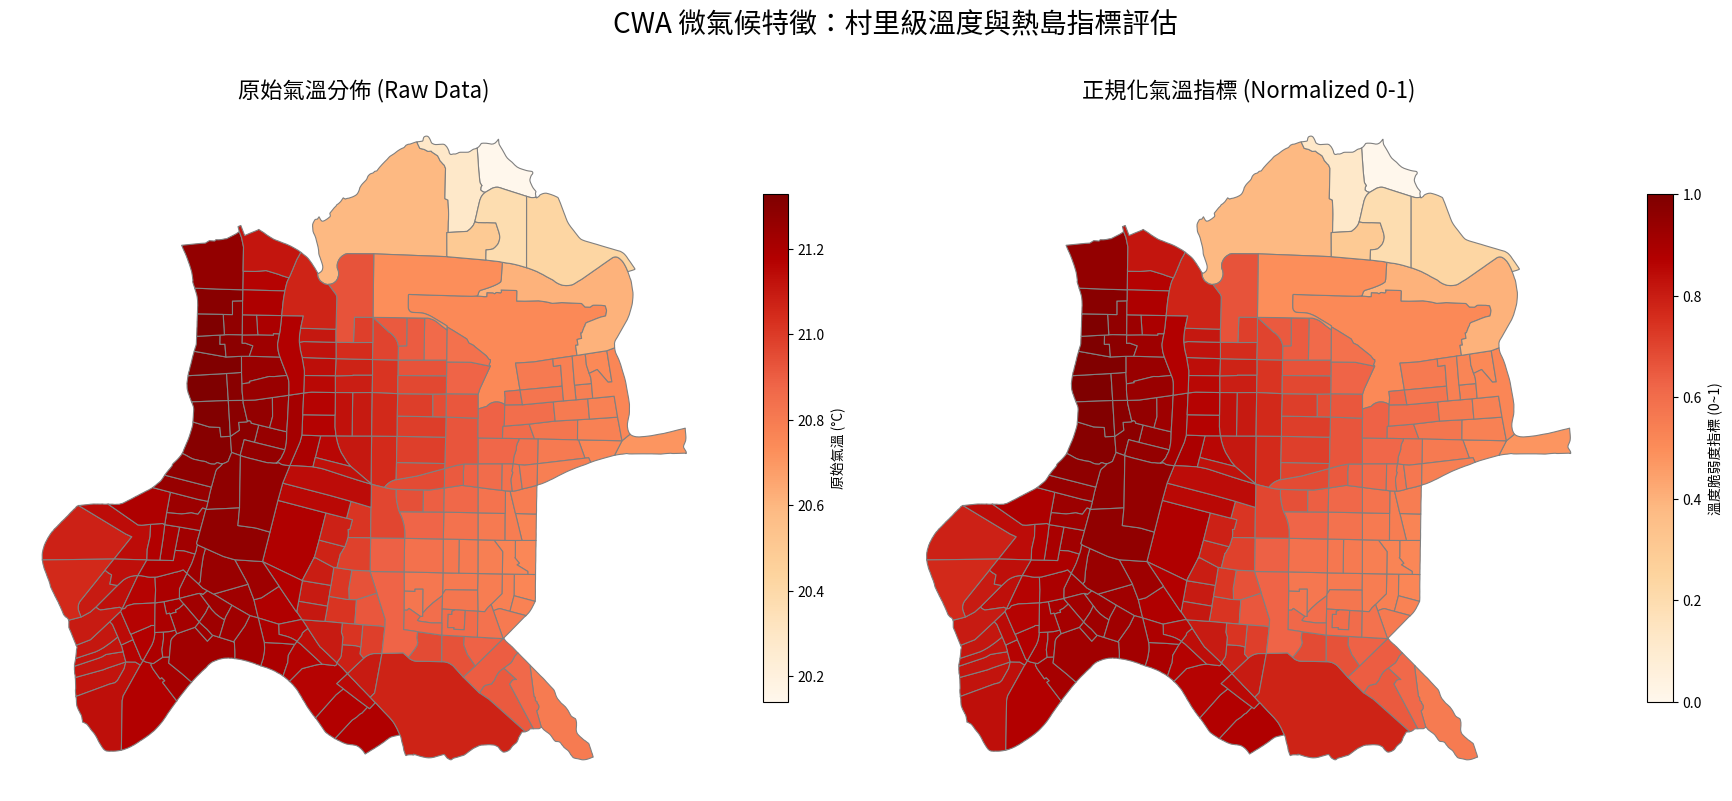

In [ ]:
import matplotlib.pyplot as plt

print("🌡️ 正在進行 CWA 氣溫變數正規化...")

# 1. 確保整合表存在，並檢查欄位
if 'gdf_villages_enriched' not in locals():
    raise ValueError("⚠️ 找不到整合統計表 gdf_villages_enriched，請先執行 Step 3-1 與 3-2！")
if 'CWA_Temperature' not in gdf_villages_enriched.columns:
    raise ValueError("⚠️ 找不到 CWA_Temperature 欄位，請確認資料是否正確內插。")

# 2. 最小-最大正規化 (Min-Max Normalization)
min_temp = gdf_villages_enriched['CWA_Temperature'].min()
max_temp = gdf_villages_enriched['CWA_Temperature'].max()

# 避免除以零的防呆機制
if max_temp == min_temp:
    gdf_villages_enriched['CWA_Temperature_Norm'] = 0.0
else:
    gdf_villages_enriched['CWA_Temperature_Norm'] = (gdf_villages_enriched['CWA_Temperature'] - min_temp) / (max_temp - min_temp)

print(f"✅ 氣溫正規化完成！(原始範圍: {min_temp:.2f}°C ~ {max_temp:.2f}°C -> 轉換為 0 ~ 1)")

# 3. 繪製雙視圖對比地圖
print("🎨 正在產生氣溫空間分佈比較圖...")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 左圖：原始數值
gdf_villages_enriched.plot(
    column='CWA_Temperature',
    cmap='OrRd',
    linewidth=0.8,
    ax=axes[0],
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "原始氣溫 (°C)", 'shrink': 0.7}
)
axes[0].set_title("原始氣溫分佈 (Raw Data)", fontsize=16, fontweight='bold')
axes[0].axis('off')

# 右圖：正規化指標
gdf_villages_enriched.plot(
    column='CWA_Temperature_Norm',
    cmap='OrRd',
    linewidth=0.8,
    ax=axes[1],
    edgecolor='gray',
    legend=True,
    vmin=0, vmax=1, # 強制圖例範圍為 0~1
    legend_kwds={'label': "溫度脆弱度指標 (0~1)", 'shrink': 0.7}
)
axes[1].set_title("正規化氣溫指標 (Normalized 0-1)", fontsize=16, fontweight='bold')
axes[1].axis('off')

fig.suptitle("CWA 微氣候特徵：村里級溫度與熱島指標評估", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Step4-2: MOENV 空氣品質正規化與雙視圖檢核

此步驟針對空氣品質指標 (AQI) 執行相同的正規化流程。
在多準則評估中，較高的 AQI 代表污染較嚴重，轉換後的指標接近 1 即代表該區的「空氣品質脆弱度」越高，屬於優先需要綠化干預（例如廣植具滯塵能力樹種）的熱點區域。

🌫️ 正在進行 MOENV 空氣品質 (AQI) 變數正規化...
✅ AQI 正規化完成！(原始範圍: 55.74 ~ 65.44 -> 轉換為 0 ~ 1)
🎨 正在產生空品空間分佈比較圖...


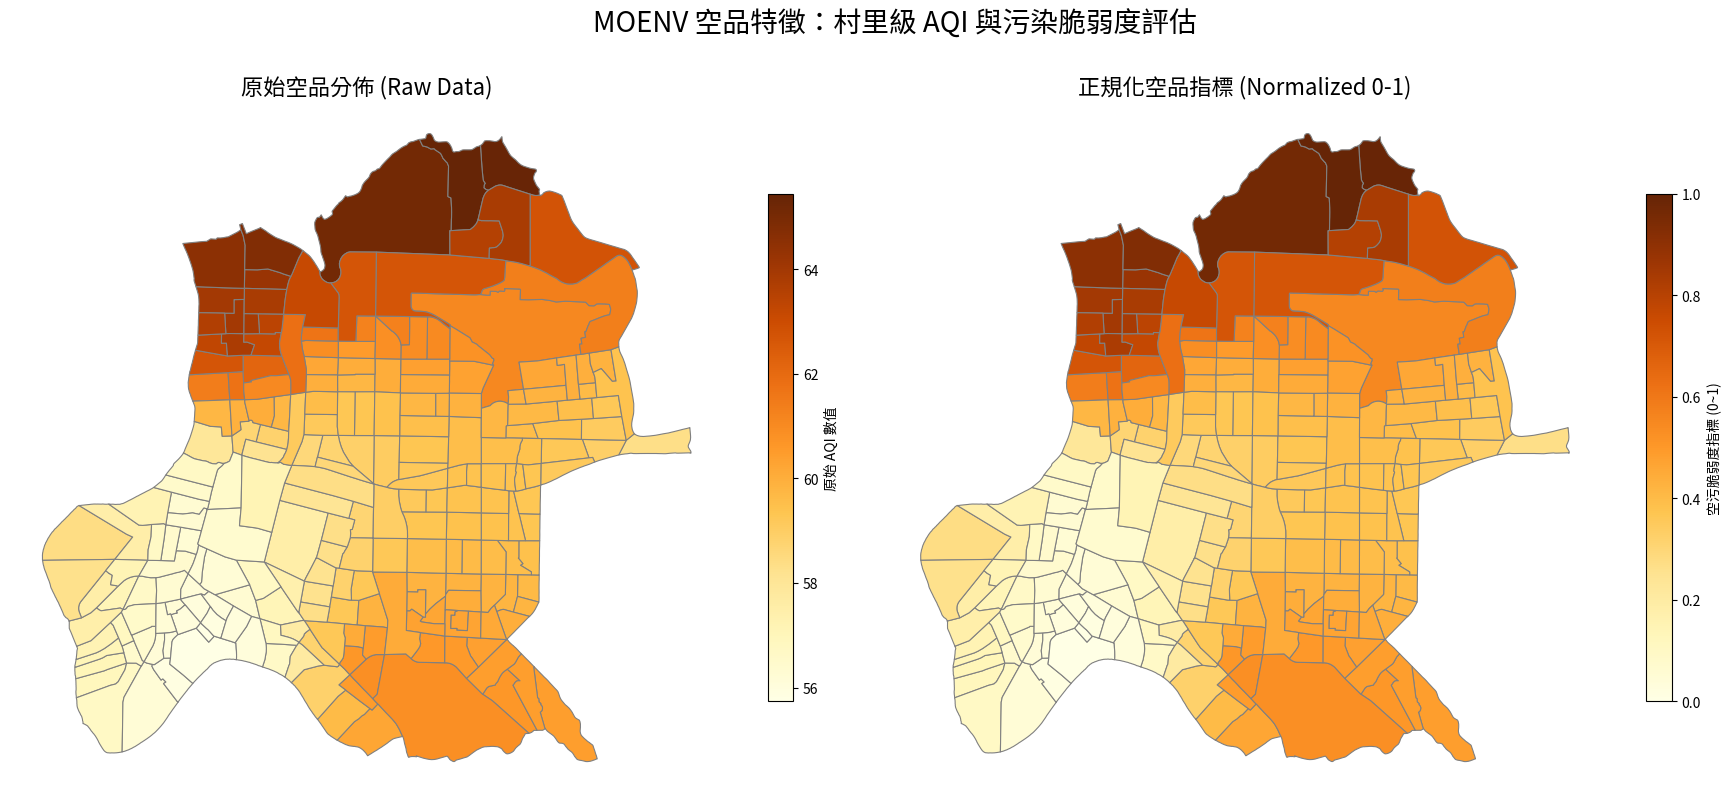

🎉 恭喜！環境變數已全數轉換為 0~1 標準化指標，隨時可送入 PCA 降維模型或 TOPSIS 矩陣中！


In [ ]:
print("🌫️ 正在進行 MOENV 空氣品質 (AQI) 變數正規化...")

if 'MOENV_AQI' not in gdf_villages_enriched.columns:
    raise ValueError("⚠️ 找不到 MOENV_AQI 欄位，請確認資料是否正確內插。")

# 1. 最小-最大正規化 (Min-Max Normalization)
min_aqi = gdf_villages_enriched['MOENV_AQI'].min()
max_aqi = gdf_villages_enriched['MOENV_AQI'].max()

if max_aqi == min_aqi:
    gdf_villages_enriched['MOENV_AQI_Norm'] = 0.0
else:
    gdf_villages_enriched['MOENV_AQI_Norm'] = (gdf_villages_enriched['MOENV_AQI'] - min_aqi) / (max_aqi - min_aqi)

print(f"✅ AQI 正規化完成！(原始範圍: {min_aqi:.2f} ~ {max_aqi:.2f} -> 轉換為 0 ~ 1)")

# 2. 繪製雙視圖對比地圖
print("🎨 正在產生空品空間分佈比較圖...")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 左圖：原始數值 (使用 YlOrBr 黃橙棕色系，適合呈現空污)
gdf_villages_enriched.plot(
    column='MOENV_AQI',
    cmap='YlOrBr',
    linewidth=0.8,
    ax=axes[0],
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "原始 AQI 數值", 'shrink': 0.7}
)
axes[0].set_title("原始空品分佈 (Raw Data)", fontsize=16, fontweight='bold')
axes[0].axis('off')

# 右圖：正規化指標
gdf_villages_enriched.plot(
    column='MOENV_AQI_Norm',
    cmap='YlOrBr',
    linewidth=0.8,
    ax=axes[1],
    edgecolor='gray',
    legend=True,
    vmin=0, vmax=1, # 強制圖例範圍為 0~1
    legend_kwds={'label': "空污脆弱度指標 (0~1)", 'shrink': 0.7}
)
axes[1].set_title("正規化空品指標 (Normalized 0-1)", fontsize=16, fontweight='bold')
axes[1].axis('off')

fig.suptitle("MOENV 空品特徵：村里級 AQI 與污染脆弱度評估", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("🎉 恭喜！環境變數已全數轉換為 0~1 標準化指標，隨時可送入 PCA 降維模型或 TOPSIS 矩陣中！")